In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

### PARAMETERS AND SYSTEM SET UP

theta 0.06253293497312401
initial state:  12001
arg arcsin: 0.0
θ= 0.0  radian,  0.0  degree
N site =  8001
Nlayer =  1
N Photon =  8001
NStates =  16002
Emin =  0.11758
β =  1052.8
τ =  0.0
ϵ0 =  0.1176
g =  0.01298 /NormN
γ =  0.0
ω (phonon) =  0.00617
ω0 =  7.81103
kz =  0.00166
mz =  5
Lz =  9448.63 , az =  75.59 , a =  22.68 , N*a =  181436.37
NSteps =  150
NTraj =  1
dtN =  25 , dtE =  1.0
θtilt 0.06253 rad, b =  1.417 Å
δz =  56.692 Å
δk =  3 1/Å
4724.31497144725


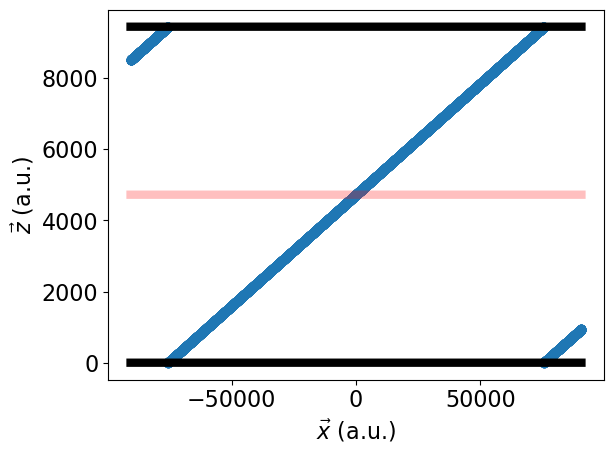

In [23]:
class parameters():
    initype = 4 #EW2KGauss = 5 (Gaussian Initial state), Absoption = 4
    amu, ps, cm, Å =  1836.0, 41341.37, 1/0.000004556, 1.8897259885789
    c, π = 137.036, np.pi
    c = c/2.4
    eV = 1/27.2114
    Photoncut = 'full' # 'cut' or 'full'
    Nsite = 8001
    Nlayer = 1
    dtN = 25
    dtE = dtN/25
    NSteps =  150 #int(0.1 * ps / dtN) # 0.1 ps
    NTraj = 1 #number of initial state sampling
    M = 1.0 #nuclear mass
    nskip = 1
    τ = 0 * 100/cm # Hopping integral contsant for cleane system
    β = 1052.8# a.u. is 300K is 1052.8
    ω = 1355/cm #(K/ms) ** 0.5 # Phonon frequency
    γ = 0 * 1.1 * 0.25*((1440/cm)**1.5) # 1000/(cm * Å)/ms**0.5
    Γ = 0 # cavity loss
    a = 12 * Å
    az = 40 * Å 
    ϵ0 = 3.2 * eV
    mz = 5 # which photonic mode -- primary
    if Nlayer%2==0:
        Rlz = np.arange(-Nlayer//2,  Nlayer//2) # sites position
    if Nlayer%2==1:
        Rlz = np.arange(-(Nlayer-1)//2, (Nlayer+1)//2)
    ######## Cavity and Fourier parameters
    Lz = 5000 * Å # 0.01 * Nsite * a * Å
    kz = mz*(np.pi/Lz)
    NormN = np.sqrt(sum(np.sin(kz * ((Rlz * az) + Lz/2))**2))
    g =  1.9 * 1500/cm
    Rn = np.arange(Nsite) - Nsite//2
    kx =  2 * π * (Rn)/(Nsite*a) # Kpoints
    a_y = 12 * Å
    ky = 2 * π * (Rn)/(Nsite*a_y)
    initKy = 50 # Initial ky
    k_yn = ky[initKy]
    ###################################################
    X_n = Rn * a # X position of sites
    X_nm = np.vstack([X_n] * Nlayer)
    delta_k = 3
    θtilt = np.arcsin(2*Lz*delta_k/(mz*Nsite*a))
    print("theta",θtilt )
    b = a * np.sin(θtilt) # distance between layers
    Z_n =  b*Rn
    δz = 30.0 * Å # distance between layers
    Z_nm = np.zeros((Nsite, Nlayer))
    for m in Rlz:
        Z_nm[:, m] = Rn * b + m * δz + Lz/2 #- b*Nsite/2
    for m in range(Nlayer):
      for n in range(Nsite):
          Z_nm[n, m] = Z_nm[n, m]%Lz
    #####################
    ω0 = c*(kz**2 + (k_yn)**2)**0.5 # Photon frequency
    ωk = np.roll( c * np.sqrt((kx - kx[Nsite//2])**2 + (k_yn)**2 + (kz)**2), -1 * (Nsite//2))
    ##### Finding Phonon cut-off
    εk = ϵ0*np.ones(Nsite)-2*τ*np.cos(kx*a) # Electronic band energies
    diff = (2*((g*NormN)**2)*ω0/ωk)/(2*(ωk-εk)**2)
    diff_tresh, diff_max = 0.005, max(abs(diff))
    if Photoncut == "full":
        diff[:]=10*diff_tresh + 10
    if Photoncut == "cut":
        diff[:int(Nsite*0.10)] = 20 * diff_max + 10
        diff[-int(Nsite*0.10):] = 20 * diff_max + 10
    mask = diff >= diff_tresh
    N_Pht = ωk[mask].shape[0] # Photon number
    NStates = Nlayer * Nsite + N_Pht # computational basis size
    Δm = 0 # Integer defining the k-point Δk ∝ Δm
    if Nlayer > 1:
        Δm = 0
    θ = np.arcsin(Δm * 2 * π / (kz*Nsite*a)) # angle of tilte to match with Δm (sinθ = Δm * 2 * π / (kz*Nsite*a) )
    sinθ = np.sin(θ)
    Emin = 0.5 * ((ϵ0 - 2*τ + ω0) - np.sqrt((ϵ0 - 2*τ - ω0)**2 + 4*((g*NormN)**2))) # Minimum energy assuming no tilte and disorder
    initState = int(Nsite * Nlayer + int(N_Pht * 0.5))
    print("initial state: ", initState)
    print("arg arcsin:", Δm * 2 * π /(kz*Nsite*a))
    print("θ=", np.round(θ,3), " radian, ", np.round(θ*180/np.pi,3), " degree")
    print("N site = ", Nsite)
    print("Nlayer = ", Nlayer)
    print("N Photon = ", N_Pht)
    print("NStates = ", NStates)
    print("Emin = ", np.round(Emin, 5))
    print("β = ", β)
    print("τ = ", np.round(τ, 5))
    print("ϵ0 = ", np.round(ϵ0,5))
    print("g = ", np.round(g*NormN, 5), "/NormN")
    print("γ = ", np.round(γ,6))
    print("ω (phonon) = ", np.round(ω, 5))
    print("ω0 = ", np.round(ω0,5))
    print("kz = ", np.round(kz,5))
    print("mz = ", mz)
    print("Lz = ", np.round(Lz,2), ", az = ", np.round(az, 2), ", a = ", np.round(a, 2), ", N*a = ", np.round(Nsite*a,2))
    print("NSteps = ", NSteps)
    print("NTraj = ", NTraj)
    print("dtN = ", np.round(dtN,4), ", dtE = ", np.round(dtE,4))
    print('θtilt', np.round(θtilt, 5), 'rad, b = ', np.round(b, 3), 'Å')
    print("δz = ", np.round(δz, 3), "Å")
    print("δk = ", delta_k, "1/Å")
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'sans-serif'})
plt.plot(parameters.X_n,np.zeros(parameters.Nsite), color='black',linewidth =6)
plt.plot(parameters.X_n,np.ones(parameters.Nsite)*parameters.Lz, color='black',linewidth = 6)
plt.plot(parameters.X_n,np.ones(parameters.Nsite)*parameters.Lz/2, color='red',linewidth = 6, alpha =0.25)
for i in range(parameters.Nlayer):
    plt.scatter(parameters.X_n,parameters.Z_nm[:,i])
plt.xlabel(r'$\vec{x}$ (a.u.)')
plt.ylabel(r'$\vec{z}$ (a.u.)')
print(parameters.Lz/2)    

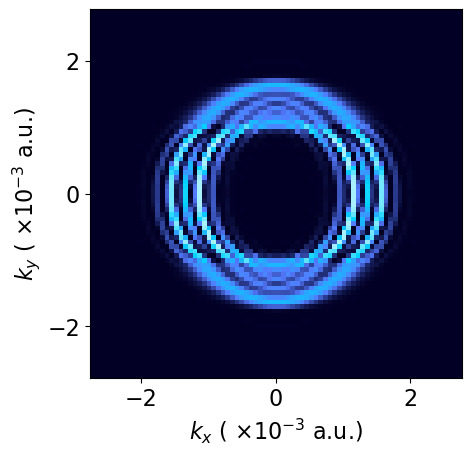

In [39]:
dat = np.loadtxt('2D_Abs_Spec_θ=0.06.txt')
length = dat.shape[0]
Full4x = np.zeros((length * 2, length * 2), dtype=float)
Full4x[length:, length:] = dat
Full4x[length:, :length] = dat[:,::-1]
Full4x[:length, :length] = dat[::-1,::-1]
Full4x[:length, length:] = dat[::-1,:]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('custom',['#020024', '#547bff', '#00d4ff', '#a9f0ff', '#a9ffe2'])
plt.figure(figsize=(5, 5/ 1.034))
maxkx = 2*np.pi/(parameters.a)*10 ## We are sampling 1% of the photonic sites, 0.01*1000 = 10
maxky = 2*np.pi/(parameters.a)*10
plt.imshow(Full4x, aspect='auto',cmap=cmap, interpolation='nearest', extent=[-maxkx, maxkx, -maxky, maxky])
#plt.colorbar(label='Intensity')
plt.xlabel('$k_x$ ( $×10^{-3}$ a.u.)')
plt.yticks([-2,0,2])
plt.ylabel('$k_y$ ( $× 10^{-3}$ a.u.)')
plt.clim(0, max(Full4x.flatten()) * 1.2)  # Set color limits to enhance visibility
#plt.title('2D Absorbtion Spectra For Tilted Multilayered System')
plt.tight_layout()